# Pion mass vs quark mass with domain-wall fermions
The Wilson version (`mfRelation.ipynb`) had to float an additive mass shift $m_c$. With DWF the shift is *measured*: $m_f = m_0 + m_{res}$, with $m_{res}$ from the midpoint correlator stored in every cache since 2026-08-24 (`mRes.ipynb`). So every $\beta=3$, $32\times64$ ensemble with a known $m_{res}$ is a point on one curve — the $m_0$ series, both $N_5$ scans and the $M_5$ scan — and the test of the picture is that they collapse onto $M_\pi = A\,m_f^{2/3}$ with $m_c \approx 0$, even though at fixed $m_0=0.05$ they span $m_f = 0.051 \ldots 0.24$.

Caveat: all boxes are $N_x=32$, so the lightest points ($m_f \lesssim 0.01$, $M_\pi L \lesssim 1$) carry finite-volume effects (see `finiteVolume.ipynb`); they are shown but flagged.

In [1]:
import os, re, glob, pickle
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.optimize import curve_fit

import schwingerModel as sim
from schwingerModel import plotting as sp
from schwingerModel.interpolator import MesonOp, mesonMultiplet
from schwingerModel.mRes import bootstrapMres, plateauReduce

sp.setStyle()

def triplet(op):
    return mesonMultiplet(op, 1)[+1]

beta, Nx, Nt = 3.0, 32, 64
nGroups = 800
pionBasis = [triplet(MesonOp("g5")), triplet(MesonOp("g5", DNum=2))]
gevpTi, shift = 2, 1
fitModel = sim.plotting.fitCurve("sinh", ti=gevpTi, shift=shift, dimt=Nt)

def yerr(err):
    return np.clip(err, 0.0, None)[::-1]

## Inventory
Every finished cache with `mres/` datasets, tagged by which scan it belongs to.

In [2]:
pat = re.compile(rf"dwf_beta_{beta}_m_(?P<m0>[0-9.]+)_Nx_{Nx}_Nt_{Nt}_N5_(?P<N5>\d+)(?:_M5_(?P<M5>[0-9.]+))?\.hdf5$")

def series(m0, N5, M5):
    if M5 != 1.0:            return "M5 scan"
    if N5 == 16:             return "m0 series"
    return "N5 scan m0=0" if m0 == 0.0 else "N5 scan m0=0.05"

ensembles = []
for path in sorted(glob.glob(f"configs/dwf_beta_{beta}_m_*_Nx_{Nx}_Nt_{Nt}_N5_*.hdf5")):
    g = pat.search(os.path.basename(path))
    if not g:
        continue
    m0, N5, M5 = float(g["m0"]), int(g["N5"]), float(g["M5"] or 1.0)
    try:
        C_PP, C_JP = sim.distillation.readMres(path)
    except (KeyError, BlockingIOError):
        print(f"skipped (no mres / locked): {os.path.basename(path)}"); continue
    if len(C_PP) < nGroups:
        print(f"skipped (still generating): {os.path.basename(path)}"); continue
    ensembles.append(dict(path=path, m0=m0, N5=N5, M5=M5, series=series(m0, N5, M5),
                          mres=bootstrapMres(C_PP, C_JP, reduce=plateauReduce((8, 30)),
                                             numResamples=2000, seed=0, progress=False)))
for e in ensembles:
    e["mf"] = e["m0"] + e["mres"][0]
    #tree-level DWF quark-field normalisation: the 4d propagator carries
    #1/[M5(2-M5)], so the physical quark mass is M5(2-M5) (m0 + m_res) — unity
    #at M5=1, 0.75 at 1.5, 0.61 at 1.625
    e["mq"] = e["M5"] * (2 - e["M5"]) * e["mf"]
    #chiral subset: residual chiral symmetry breaking small in ABSOLUTE terms
    #(a m_res <= 0.012: N5 >= 8 at M5 ~ 1 — at m0 = 0 m_res IS the mass, so a
    #relative criterion would wrongly drop the lightest points) and M5 in the
    #range where the normalisation is a modest, tree-level-like correction
    e["chiral"] = (e["mres"][0] <= 0.012) and (1.0 <= e["M5"] <= 1.375)
print(f"{len(ensembles)} ensembles;", {s: sum(e['series'] == s for e in ensembles)
                                       for s in ("m0 series", "N5 scan m0=0.05", "N5 scan m0=0", "M5 scan")})

34 ensembles; {'m0 series': 5, 'N5 scan m0=0.05': 7, 'N5 scan m0=0': 3, 'M5 scan': 19}


## Pion masses
GEVP on the two-operator pion basis, correlated sinh plateau fit — the `finiteVolume.ipynb` setup. Fit windows by expected mass: light ($m_f<0.03$) $[7,26]$, otherwise $[7,30]$. Results are cached in `mfRelationDwf.pkl` keyed by file and mtime, so a re-run only measures new caches.

In [3]:
cacheFile = "mfRelationDwf.pkl"
cache = pickle.load(open(cacheFile, "rb")) if os.path.exists(cacheFile) else {}

def key(e):
    return (os.path.basename(e["path"]), os.path.getmtime(e["path"]))

todo = [e for e in ensembles if key(e) not in cache]
print(f"{len(todo)} ensembles to measure, {len(ensembles) - len(todo)} cached")

# measureEnsemble parallelises over configs internally: run the ensembles one after another
measured = []
for e in todo:
    meta = sim.distillation.readDistillMeta(e["path"])
    measured.append(sim.GEVP.measureEnsemble(e["path"], meta.configIndices, pionBasis))

def fitWindow(mf):
    return [7, 26] if mf < 0.03 else [7, 30]

fits = Parallel(n_jobs=-1)(
    delayed(sim.GEVP.bootstrapMasses)(m, ti=gevpTi, shift=shift, fitT=fitWindow(e["mf"]),
                                      fitForm="sinh", withAmp=True, numResamples=2000,
                                      seed=0, progress=False)
    for e, m in zip(todo, measured))
for e, f in zip(todo, fits):
    cache[key(e)] = (fitWindow(e["mf"]), f)
pickle.dump(cache, open(cacheFile, "wb"))

for e in ensembles:
    e["fitT"], e["fit"] = cache[key(e)]
    e["mpi"] = e["fit"].masses[0][0, 0]                 # ground state energy
    e["mpiErr"] = np.clip(e["fit"].masses[1][:, 0, 0], 0.0, None)   # [high-c, c-low]

print(f"{'series':<16}{'m0':>6}{'N5':>4}{'M5':>7}{'m_res':>14}{'m_f':>9}{'m_q':>9}{'a m_pi':>14}  window  chiral")
for e in sorted(ensembles, key=lambda e: e["mq"]):
    print(f"{e['series']:<16}{e['m0']:>6}{e['N5']:>4}{e['M5']:>7}"
          f"{sp.fmtErr(e['mres'][0], e['mres'][1].max()):>14}{e['mf']:>9.4f}{e['mq']:>9.4f}"
          f"{sp.fmtErr(e['mpi'], e['mpiErr'].max()):>14}  {e['fitT']}  {'yes' if e['chiral'] else '--'}")

0 ensembles to measure, 34 cached
series              m0  N5     M5         m_res      m_f      m_q        a m_pi  window  chiral
N5 scan m0=0       0.0  24    1.0   0.00158(26)   0.0016   0.0016    0.0913(56)  [7, 26]  yes
m0 series          0.0  16    1.0   0.00285(20)   0.0028   0.0028    0.0960(55)  [7, 26]  yes
N5 scan m0=0       0.0  12    1.0   0.00488(22)   0.0049   0.0049    0.1042(45)  [7, 26]  yes
N5 scan m0=0       0.0   8    1.0   0.01122(28)   0.0112   0.0112    0.1006(40)  [7, 26]  yes
m0 series         0.01  16    1.0  0.002661(97)   0.0127   0.0127    0.1160(25)  [7, 26]  yes
m0 series         0.02  16    1.0  0.002560(77)   0.0226   0.0226    0.1500(12)  [7, 26]  yes
M5 scan           0.05  24  1.625  0.000961(26)   0.0510   0.0311   0.20550(81)  [7, 30]  --
M5 scan           0.05  16   1.75  0.027849(74)   0.0778   0.0341  0.18276(100)  [7, 30]  --
M5 scan           0.05  24    1.5  0.000618(31)   0.0506   0.0380   0.22317(84)  [7, 30]  --
M5 scan           0.05  16 

## Before and after
Left: against the bare mass, where every $m_0=0.05$ ensemble sits on one vertical line. Middle: against $m_f = m_0 + m_{res}$ — the $M_5$ scan still scatters, because the DWF quark field is normalised by $M_5(2-M_5)$ at tree level. Right: against $m_q = M_5(2-M_5)\,(m_0 + m_{res})$; filled grey points are outside the chiral subset ($m_{res} > m_f/4$, or $M_5 \notin [1, 1.375]$).

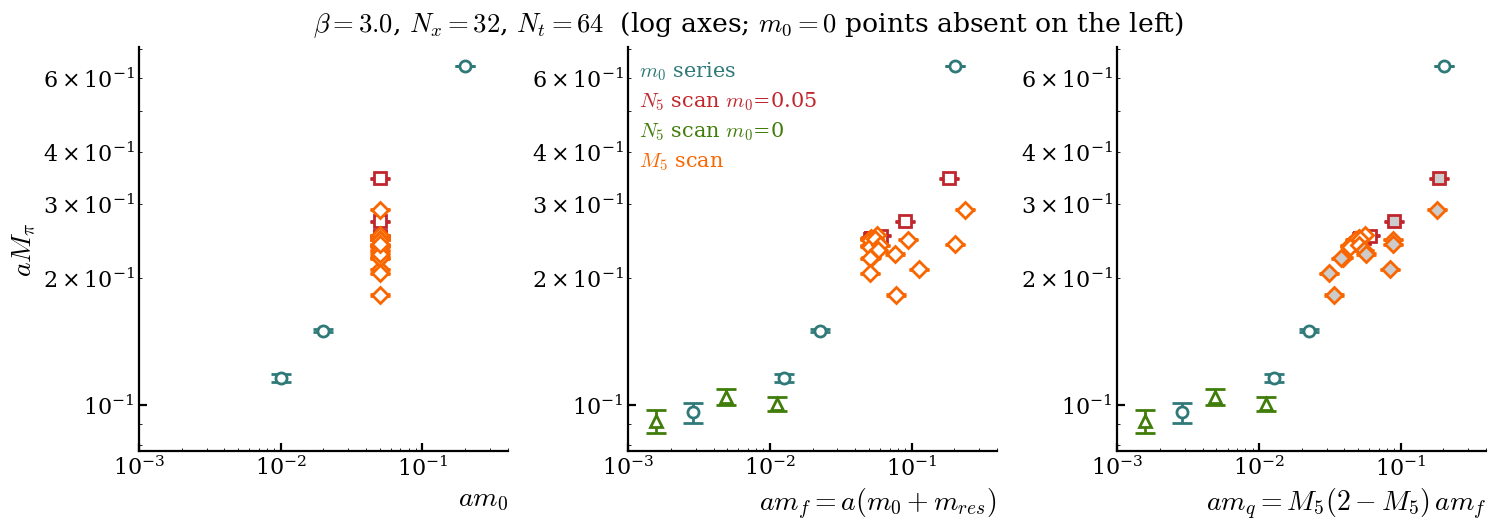

In [4]:
seriesStyle = {"m0 series":      (sp.JLab_blue,   "o"),
               "N5 scan m0=0.05": (sp.JLab_red,    "s"),
               "N5 scan m0=0":    (sp.JLab_green,  "^"),
               "M5 scan":         (sp.JLab_orange, "D")}

def scatter(ax, xkey, greyNonChiral=False):
    for s, (col, mk) in seriesStyle.items():
        for chiral in (True, False):
            es = [e for e in ensembles if e["series"] == s and e["chiral"] == chiral]
            if not es:
                continue
            x = np.array([e[xkey] for e in es]); y = np.array([e["mpi"] for e in es])
            err = np.array([e["mpiErr"] for e in es]).T
            kw = dict(sp.eb_kw)
            if greyNonChiral and not chiral:
                kw["mfc"] = "0.8"
            ax.errorbar(x, y, yerr=yerr(err), marker=mk, color=col, mec=col, **kw)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), layout="constrained")
fig.get_layout_engine().set(w_pad=0.12)
for ax, xkey, lab in zip(axes, ("m0", "mf", "mq"),
                         (r"$a m_0$", r"$a m_f = a(m_0 + m_{res})$", r"$a m_q = M_5(2-M_5)\,a m_f$")):
    scatter(ax, xkey, greyNonChiral=(xkey == "mq"))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(lab, loc="right")
    ax.set_xlim(1e-3, 0.4)
axes[0].set_ylabel(r"$a M_\pi$")
for j, (s, (col, mk)) in enumerate(seriesStyle.items()):
    axes[1].text(0.03, 0.97 - 0.075 * j, s.replace("m0", "$m_0$").replace("N5", "$N_5$").replace("M5", "$M_5$"),
                 color=col, ha="left", va="top", transform=axes[1].transAxes, fontsize=15,
                 zorder=5, bbox=sp.TEXTBOX)
fig.suptitle(rf"$\beta={beta}$, $N_x={Nx}$, $N_t={Nt}$  (log axes; $m_0=0$ points absent on the left)")
fig.savefig(f"figs/pionMassVsMf_beforeAfter_beta{beta}_Nx{Nx}_Nt{Nt}.pdf")
plt.show()

## The $2/3$ law
$M_\pi = A\,|m_q - m_c|^{2/3}$ with $m_c$ floated (it should now be consistent with 0), with $m_c \equiv 0$, and with a free power, on the chiral subset. The $m_0=0$ points ($M_\pi L \approx 3$ at $N_x=32$) are finite-volume affected — `finiteVolume.ipynb` — so the fits are repeated without them (`lightCut`). The linearised check is $M_\pi^{3/2}$ vs $m_q$: a straight line through the origin.

chiral subset, all masses (22 points):
  2/3 law, m_c free : A = 1.8228(23), a m_c = 0.00048(11), chi2/dof = 206.0
  2/3 law, m_c = 0  : A = 1.8142(11), chi2/dof = 197.1
  free power, m_c=0 : A = 1.8949(45), p = 0.68409(93), chi2/dof = 189.6
chiral subset, m_q >= 0.02 (17 points):
  2/3 law, m_c free : A = 1.8451(25), a m_c = 0.00173(12), chi2/dof = 231.7
  2/3 law, m_c = 0  : A = 1.8138(11), chi2/dof = 229.8
  free power, m_c=0 : A = 1.9010(45), p = 0.68548(93), chi2/dof = 218.2


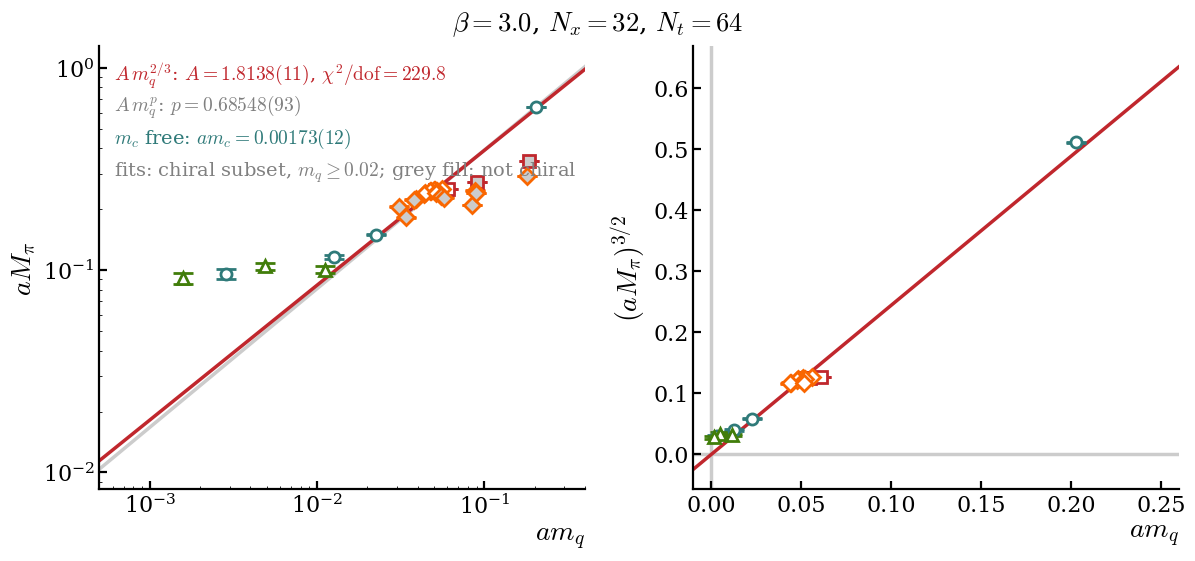

In [5]:
law23  = lambda m, A, mc: A * np.abs(m - mc)**(2/3)
law23z = lambda m, A: A * np.abs(m)**(2/3)
lawP   = lambda m, A, p: A * np.abs(m)**p

mf  = np.array([e["mq"] for e in ensembles]); mpi = np.array([e["mpi"] for e in ensembles])
sig = np.array([e["mpiErr"].mean() for e in ensembles])
chiral = np.array([e["chiral"] for e in ensembles])
lightCut = 0.02                                     # m_q below this: N_x=32 is not big enough
for label, ok in (("chiral subset, all masses", np.isfinite(mpi) & chiral),
                  (f"chiral subset, m_q >= {lightCut}", np.isfinite(mpi) & chiral & (mf >= lightCut))):
    p23, c23 = curve_fit(law23, mf[ok], mpi[ok], p0=(1.4, 0.0), sigma=sig[ok], absolute_sigma=True)
    pz, cz   = curve_fit(law23z, mf[ok], mpi[ok], p0=(1.4,), sigma=sig[ok], absolute_sigma=True)
    pP, cP   = curve_fit(lawP, mf[ok], mpi[ok], p0=(1.4, 0.67), sigma=sig[ok], absolute_sigma=True)
    chi2 = lambda f, p: np.sum(((mpi[ok] - f(mf[ok], *p)) / sig[ok])**2) / max(ok.sum() - len(p), 1)
    e23, ez, eP = (np.sqrt(np.diag(c)) for c in (c23, cz, cP))
    print(f"{label} ({ok.sum()} points):")
    print(f"  2/3 law, m_c free : A = {sp.fmtErr(p23[0], e23[0])}, a m_c = {sp.fmtErr(p23[1], e23[1])}, chi2/dof = {chi2(law23, p23):.1f}")
    print(f"  2/3 law, m_c = 0  : A = {sp.fmtErr(pz[0], ez[0])}, chi2/dof = {chi2(law23z, pz):.1f}")
    print(f"  free power, m_c=0 : A = {sp.fmtErr(pP[0], eP[0])}, p = {sp.fmtErr(pP[1], eP[1])}, chi2/dof = {chi2(lawP, pP):.1f}")
#the plots use the last (heavier) fit set

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), layout="constrained")
fig.get_layout_engine().set(w_pad=0.12)
xs = np.geomspace(5e-4, 0.4, 200)
ax = axes[0]
ax.plot(xs, law23z(xs, *pz), color=sp.JLab_red, lw=sp.LW, zorder=2)
ax.plot(xs, lawP(xs, *pP), color=sp.GREY, lw=sp.LW, zorder=1)
scatter(ax, "mq", greyNonChiral=True)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$a m_q$", loc="right"); ax.set_ylabel(r"$a M_\pi$")
ax.set_xlim(5e-4, 0.4)
lines = [(rf"$A\,m_q^{{2/3}}$: $A = {sp.fmtErr(pz[0], ez[0])}$, $\chi^2/\mathrm{{dof}} = {chi2(law23z, pz):.1f}$", sp.JLab_red),
         (rf"$A\,m_q^{{p}}$: $p = {sp.fmtErr(pP[1], eP[1])}$", "0.5"),
         (rf"$m_c$ free: $a m_c = {sp.fmtErr(p23[1], e23[1])}$", sp.JLab_blue),
         (rf"fits: chiral subset, $m_q \geq {lightCut}$; grey fill: not chiral", "0.5")]
for j, (txt, col) in enumerate(lines):
    ax.text(0.03, 0.97 - 0.075 * j, txt, color=col, ha="left", va="top",
            transform=ax.transAxes, fontsize=14, zorder=5, bbox=sp.TEXTBOX)

ax = axes[1]
ax.axhline(0.0, color=sp.GREY, lw=sp.LW, zorder=0); ax.axvline(0.0, color=sp.GREY, lw=sp.LW, zorder=0)
xl = np.linspace(-0.01, 0.26, 100)
ax.plot(xl, (pz[0]**1.5) * xl, color=sp.JLab_red, lw=sp.LW, zorder=2)
for s, (col, mk) in seriesStyle.items():
    idx = [i for i, e in enumerate(ensembles) if e["series"] == s and chiral[i]]
    if idx:
        y = mpi[idx]**1.5; ey = 1.5 * np.sqrt(np.abs(mpi[idx])) * sig[idx]
        ax.errorbar(mf[idx], y, yerr=ey, marker=mk, color=col, mec=col, **sp.eb_kw)
ax.set_xlabel(r"$a m_q$", loc="right"); ax.set_ylabel(r"$(a M_\pi)^{3/2}$")
ax.set_xlim(-0.01, 0.26)
fig.suptitle(rf"$\beta={beta}$, $N_x={Nx}$, $N_t={Nt}$")
fig.savefig(f"figs/pionMassVsMf_beta{beta}_Nx{Nx}_Nt{Nt}.pdf")
plt.show()

## Infinite-volume pion mass vs quark mass
The quantity that actually tests the chiral law: $m_\pi^\infty$ from the $N_x = 8\ldots64$ scans in `finiteVolume.ipynb` (written to `finiteVolume_mInf.pkl` by that notebook), against $m_q = m_0 + m_{res}$ from the $N_x=32$ caches. The chiral point's asymptote comes from the $m_\infty + c/L$ hybrid and is consistent with zero, so it is drawn but not fitted. The $N_x=32$ points from above are single-volume masses and are not shown here.

m_pi^inf fits, light only (3 points, m_q <= 0.06):
  2/3 law, m_c = 0  : A = 1.7707(32), chi2/dof = 0.4
  free power, m_c=0 : A = 1.791(37), p = 0.6705(68), chi2/dof = 0.4
m_pi^inf fits, all massive (4 points):
  2/3 law, m_c = 0  : A = 1.8404(12), chi2/dof = 189.8
  2/3 law, m_c free : A = 1.8671(17), a m_c = 0.00290(13), chi2/dof = 66.6
  free power, m_c=0 : A = 1.9438(47), p = 0.6971(13), chi2/dof = 8.0
  m0 =   0.0:  a m_q = 0.00285   a m_pi^inf = 0.017(32)   (sqrt(m^2+(c/L)^2))
  m0 =  0.01:  a m_q = 0.01266   a m_pi^inf = 0.0967(19)   (exp plateau)
  m0 =  0.02:  a m_q = 0.02256   a m_pi^inf = 0.14071(87)   (exp plateau)
  m0 =  0.05:  a m_q = 0.05250   a m_pi^inf = 0.24835(46)   (exp plateau)
  m0 =   0.2:  a m_q = 0.20250   a m_pi^inf = 0.63865(44)   (exp plateau)


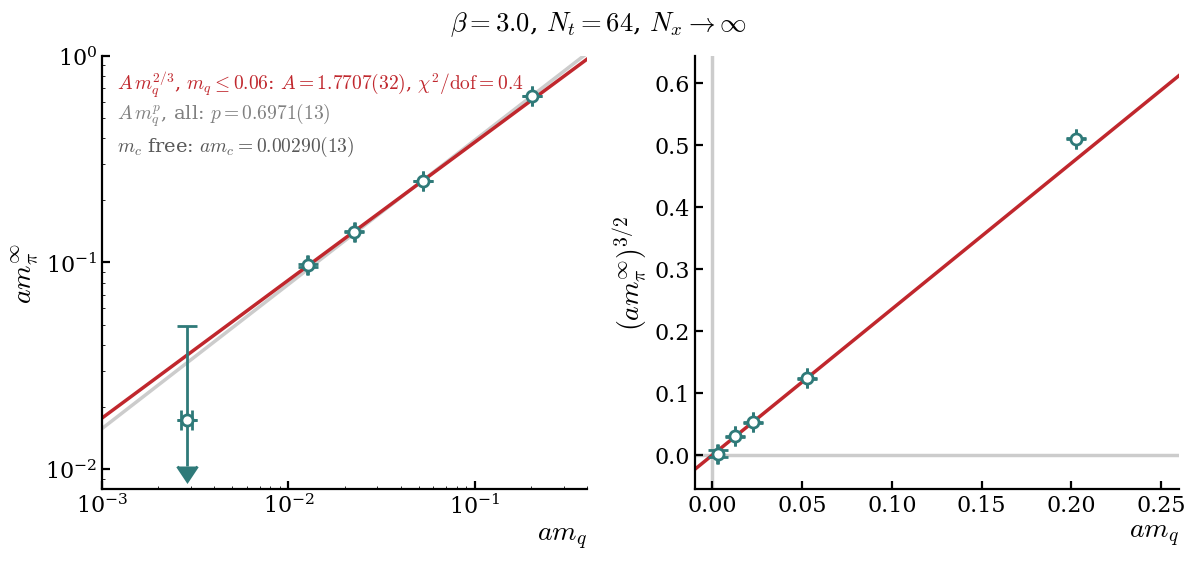

In [6]:
mInfFile = "finiteVolume_mInf.pkl"
if os.path.exists(mInfFile):
    mInfTable = pickle.load(open(mInfFile, "rb"))
    keys = sorted(mInfTable, key=float)
    xq  = np.array([mInfTable[k]["mq"] for k in keys]);  dxq = np.array([mInfTable[k]["dmq"] for k in keys])
    yI  = np.array([mInfTable[k]["mInf"] for k in keys]); dyI = np.array([mInfTable[k]["dmInf"] for k in keys])
    fitMask = yI > 3 * dyI                      # the chiral point (m_inf ~ 0) cannot enter a log fit

    pzI, czI = curve_fit(law23z, xq[fitMask], yI[fitMask], p0=(1.4,), sigma=dyI[fitMask], absolute_sigma=True)
    p23I, c23I = curve_fit(law23, xq[fitMask], yI[fitMask], p0=(1.4, 0.0), sigma=dyI[fitMask], absolute_sigma=True)
    pPI, cPI = curve_fit(lawP, xq[fitMask], yI[fitMask], p0=(1.4, 0.67), sigma=dyI[fitMask], absolute_sigma=True)
    chi2I = lambda f, p: np.sum(((yI[fitMask] - f(xq[fitMask], *p)) / dyI[fitMask])**2) / max(fitMask.sum() - len(p), 1)
    ezI, e23I, ePI = (np.sqrt(np.diag(c)) for c in (czI, c23I, cPI))
    light = fitMask & (xq <= 0.06)                 # the small-mass regime: m/g = m_q sqrt(beta) < 0.1
    pzL, czL = curve_fit(law23z, xq[light], yI[light], p0=(1.4,), sigma=dyI[light], absolute_sigma=True)
    pPL, cPL = curve_fit(lawP, xq[light], yI[light], p0=(1.4, 0.67), sigma=dyI[light], absolute_sigma=True)
    chi2L = lambda f, p: np.sum(((yI[light] - f(xq[light], *p)) / dyI[light])**2) / max(light.sum() - len(p), 1)
    print(f"m_pi^inf fits, light only ({light.sum()} points, m_q <= 0.06):")
    print(f"  2/3 law, m_c = 0  : A = {sp.fmtErr(pzL[0], np.sqrt(czL[0, 0]))}, chi2/dof = {chi2L(law23z, pzL):.1f}")
    print(f"  free power, m_c=0 : A = {sp.fmtErr(pPL[0], np.sqrt(cPL[0, 0]))}, p = {sp.fmtErr(pPL[1], np.sqrt(cPL[1, 1]))}, chi2/dof = {chi2L(lawP, pPL):.1f}")
    print(f"m_pi^inf fits, all massive ({fitMask.sum()} points):")
    print(f"  2/3 law, m_c = 0  : A = {sp.fmtErr(pzI[0], ezI[0])}, chi2/dof = {chi2I(law23z, pzI):.1f}")
    print(f"  2/3 law, m_c free : A = {sp.fmtErr(p23I[0], e23I[0])}, a m_c = {sp.fmtErr(p23I[1], e23I[1])}, chi2/dof = {chi2I(law23, p23I):.1f}")
    print(f"  free power, m_c=0 : A = {sp.fmtErr(pPI[0], ePI[0])}, p = {sp.fmtErr(pPI[1], ePI[1])}, chi2/dof = {chi2I(lawP, pPI):.1f}")
    for k, x, dx, y, dy in zip(keys, xq, dxq, yI, dyI):
        print(f"  m0 = {k:>5}:  a m_q = {x:.5f}   a m_pi^inf = {sp.fmtErr(y, dy)}   ({mInfTable[k]['model']})")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), layout="constrained")
    fig.get_layout_engine().set(w_pad=0.12)
    ax = axes[0]
    xs = np.geomspace(1e-3, 0.4, 200)
    ax.plot(xs, law23z(xs, *pzL), color=sp.JLab_red, lw=sp.LW, zorder=2)      # light-only 2/3 law
    ax.plot(xs, lawP(xs, *pPI), color=sp.GREY, lw=sp.LW, zorder=1)             # free power, all massive
    ax.errorbar(xq[fitMask], yI[fitMask], xerr=dxq[fitMask], yerr=dyI[fitMask], marker="o",
                color=sp.JLab_blue, mec=sp.JLab_blue, **sp.eb_kw)
    #points whose lower error reaches zero (the chiral point): the marker sits at
    #its central value with the upper arm drawn normally, and the lower arm is an
    #ARROW to the axis floor -- "consistent with anything below this"
    yFloor = 8e-3
    lim = (~fitMask) & (yI > yFloor)
    if lim.any():
        #uplims draws the lower arm as an arrow and suppresses the upper one, so
        #the upper arm is a second call; the arrow stops above the floor so its
        #head is not clipped by the axis
        ax.errorbar(xq[lim], yI[lim], xerr=dxq[lim], yerr=[np.zeros(lim.sum()), dyI[lim]],
                    marker="o", color=sp.JLab_blue, mec=sp.JLab_blue, **sp.eb_kw)
        ax.errorbar(xq[lim], yI[lim], yerr=[yI[lim] - 1.3 * yFloor, np.zeros(lim.sum())], uplims=True,
                    marker="none", color=sp.JLab_blue, **{k: v for k, v in sp.eb_kw.items() if k not in ("ms", "mfc", "mew")})
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(1e-3, 0.4); ax.set_ylim(yFloor, 1.0)
    ax.set_xlabel(r"$a m_q$", loc="right"); ax.set_ylabel(r"$a m_\pi^\infty$")
    lines = [(rf"$A\,m_q^{{2/3}}$, $m_q \leq 0.06$: $A = {sp.fmtErr(pzL[0], np.sqrt(czL[0, 0]))}$, $\chi^2/\mathrm{{dof}} = {chi2L(law23z, pzL):.1f}$", sp.JLab_red),
             (rf"$A\,m_q^{{p}}$, all: $p = {sp.fmtErr(pPI[1], ePI[1])}$", "0.5"),
             (rf"$m_c$ free: $a m_c = {sp.fmtErr(p23I[1], e23I[1])}$", "0.35")]
    for j, (txt, col) in enumerate(lines):
        ax.text(0.03, 0.97 - 0.075 * j, txt, color=col, ha="left", va="top",
                transform=ax.transAxes, fontsize=14, zorder=5, bbox=sp.TEXTBOX)

    ax = axes[1]                                # linearised, chiral point included
    ax.axhline(0.0, color=sp.GREY, lw=sp.LW, zorder=0); ax.axvline(0.0, color=sp.GREY, lw=sp.LW, zorder=0)
    xl = np.linspace(-0.01, 0.26, 100)
    ax.plot(xl, (pzL[0]**1.5) * xl, color=sp.JLab_red, lw=sp.LW, zorder=2)
    ax.errorbar(xq, np.abs(yI)**1.5 * np.sign(yI), xerr=dxq, yerr=1.5 * np.sqrt(np.abs(yI)) * dyI, marker="o",
                color=sp.JLab_blue, mec=sp.JLab_blue, **sp.eb_kw)
    ax.set_xlabel(r"$a m_q$", loc="right"); ax.set_ylabel(r"$(a m_\pi^\infty)^{3/2}$")
    ax.set_xlim(-0.01, 0.26)
    fig.suptitle(rf"$\beta={beta}$, $N_t={Nt}$, $N_x \to \infty$")
    fig.savefig(f"figs/pionMassInfVsMq_beta{beta}_Nt{Nt}.pdf")
    plt.show()
else:
    print(f"{mInfFile} not found: run finiteVolume.ipynb first")